In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)


def find_project_root():
    """Find the project root without using an absolute path."""
    current = Path.cwd().resolve()

    for candidate in [current] + list(current.parents):
        if (
            (candidate / "experiment_results").exists()
            and (
                (candidate / "src").exists()
                or (candidate / "simulator.py").exists()
            )
        ):
            return candidate

    raise FileNotFoundError(
        "Project root was not found. "
        "Please run this notebook from inside the project folder."
    )


PROJECT_ROOT = find_project_root()

RESULT_DIR = (
    PROJECT_ROOT
    / "experiment_results"
    / "proportional_scaling"
    / "rho0p75"
)

FIGURE_DIR = PROJECT_ROOT / "Figs"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RHO = 0.75
ALPHA_R_LABEL = "alphaR10000"

FIGSIZE = (7, 5)
DPI = 300

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULT_DIR:", RESULT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)

PROJECT_ROOT: C:\Users\caoxb\PycharmProjects\ATM_simulation
RESULT_DIR: C:\Users\caoxb\PycharmProjects\ATM_simulation\experiment_results\proportional_scaling\rho0p75
FIGURE_DIR: C:\Users\caoxb\PycharmProjects\ATM_simulation\Figs


In [2]:
def load_proportional_results(turn_on_mode):
    """
    Load selected Nelder-Mead best-result files for one turn-on mode.
    One threshold pair is selected for each n by the lowest mean objective.
    """
    base_dir = (
        RESULT_DIR
        / turn_on_mode
        / ALPHA_R_LABEL
        / "nelder_mead"
    )

    result_files = sorted(
        base_dir.glob("n*/nelder_mead_best_result_by_seed_*.csv"),
        key=lambda path: int(path.parent.name.replace("n", ""))
    )

    if not result_files:
        raise FileNotFoundError(f"No result files found under {base_dir}")

    records = []

    for file in result_files:
        n = int(file.parent.name.replace("n", ""))
        result_df = pd.read_csv(file)

        if "best_T_i" not in result_df.columns and "T_i" in result_df.columns:
            result_df["best_T_i"] = result_df["T_i"]

        if "best_T_o" not in result_df.columns and "T_o" in result_df.columns:
            result_df["best_T_o"] = result_df["T_o"]

        required_columns = [
            "best_T_i",
            "best_T_o",
            "selected_objective",
            "average_power",
            "average_response_time",
        ]

        missing_columns = [
            column for column in required_columns
            if column not in result_df.columns
        ]

        if missing_columns:
            raise KeyError(
                f"Missing columns in {file}: {missing_columns}"
            )

        candidate_df = (
            result_df
            .groupby(["best_T_i", "best_T_o"], as_index=False)
            .agg(
                mean_objective=("selected_objective", "mean"),
                mean_power=("average_power", "mean"),
                mean_response_time=("average_response_time", "mean"),
                num_records=("selected_objective", "count"),
            )
            .sort_values("mean_objective")
            .reset_index(drop=True)
        )

        best_row = candidate_df.iloc[0]

        records.append(
            {
                "turn_on_mode": turn_on_mode,
                "num_servers": n,
                "best_T_i": best_row["best_T_i"],
                "best_T_o": best_row["best_T_o"],
                "mean_objective": best_row["mean_objective"],
                "mean_power": best_row["mean_power"],
                "mean_response_time": best_row["mean_response_time"],
                "num_records": best_row["num_records"],
            }
        )

    selected_df = (
        pd.DataFrame(records)
        .sort_values("num_servers")
        .reset_index(drop=True)
    )

    selected_df["T_i_over_n"] = (
        selected_df["best_T_i"] / selected_df["num_servers"]
    )

    selected_df["abs_T_o"] = selected_df["best_T_o"].abs()

    selected_df["T_o_over_n"] = (
        selected_df["best_T_o"] / selected_df["num_servers"]
    )

    selected_df["abs_T_o_over_n"] = (
        selected_df["abs_T_o"] / selected_df["num_servers"]
    )

    selected_df["sqrt_n"] = np.sqrt(selected_df["num_servers"])

    return selected_df


queue_df = load_proportional_results("queue_based")
idle_df = load_proportional_results("idle_based")

In [3]:
def save_figure(filename):
    plt.savefig(
        FIGURE_DIR / filename,
        dpi=DPI,
    )
    plt.show()


def plot_threshold_ratio(df, y_column, y_label, title, filename):
    plot_df = df.sort_values("num_servers")

    fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

    ax.plot(
        plot_df["num_servers"],
        plot_df[y_column],
        marker="o",
        linewidth=2,
    )

    ax.set_xlabel("Number of servers $n$")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(alpha=0.3)

    save_figure(filename)

## Queue-based Turn Off Threshold $T_i$

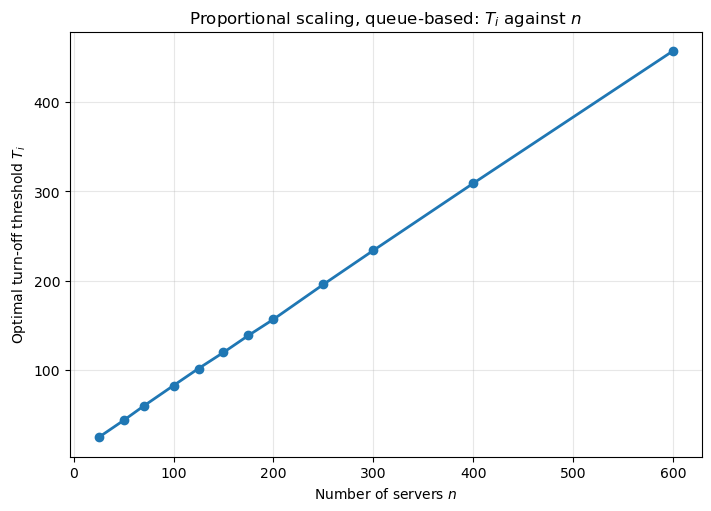

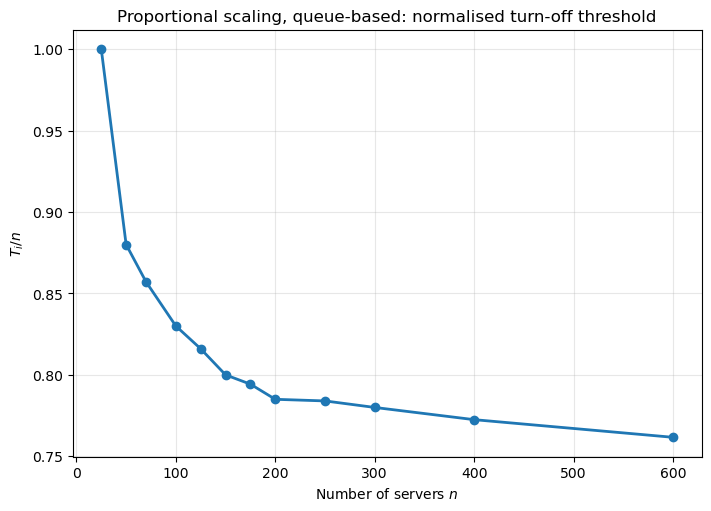

In [4]:
queue_plot_df = (
    queue_df
    .sort_values("num_servers")
    .copy()
)

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(
    queue_plot_df["num_servers"],
    queue_plot_df["best_T_i"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("Number of servers $n$")
ax.set_ylabel("Optimal turn-off threshold $T_i$")
ax.set_title("Proportional scaling, queue-based: $T_i$ against $n$")
ax.grid(alpha=0.3)

plt.savefig(
    FIGURE_DIR / "06_queue_based_proportional_Ti_vs_n.png",
    dpi=DPI,
)

plt.show()

plot_threshold_ratio(
    queue_df,
    y_column="T_i_over_n",
    y_label="$T_i/n$",
    title="Proportional scaling, queue-based: normalised turn-off threshold",
    filename="06_queue_based_proportional_Ti_over_n.png",
)

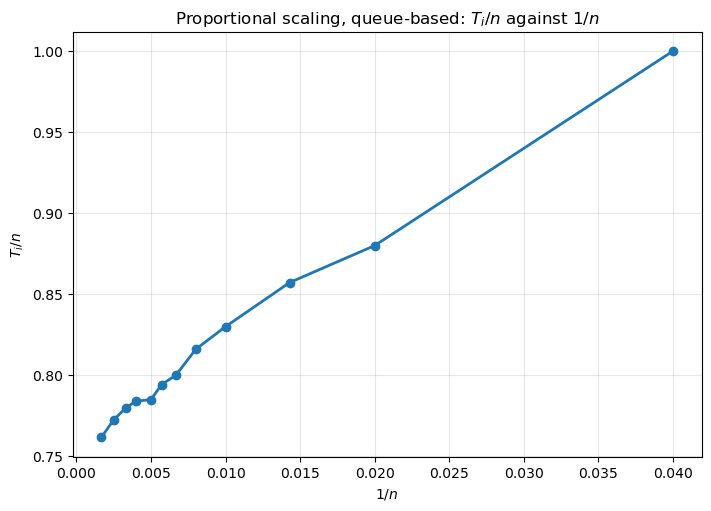

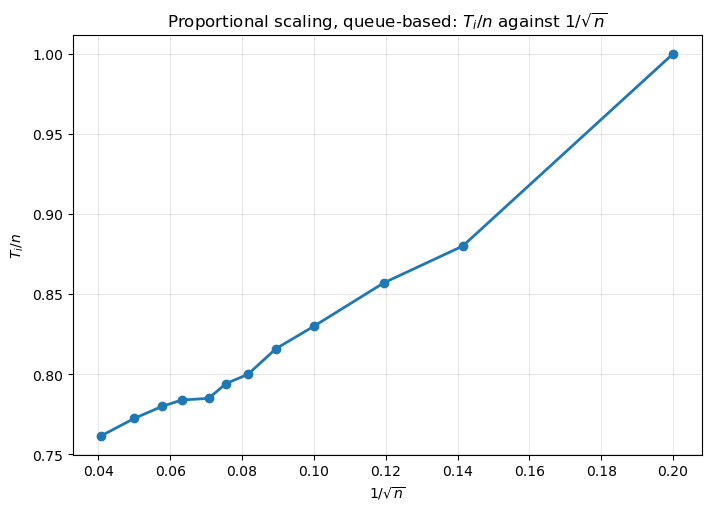

In [5]:
queue_plot_df = queue_plot_df.copy()
queue_plot_df["inv_n"] = 1 / queue_plot_df["num_servers"]
queue_plot_df["inv_sqrt_n"] = 1 / np.sqrt(queue_plot_df["num_servers"])

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(
    queue_plot_df["inv_n"],
    queue_plot_df["T_i_over_n"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("$1/n$")
ax.set_ylabel("$T_i/n$")
ax.set_title("Proportional scaling, queue-based: $T_i/n$ against $1/n$")
ax.grid(alpha=0.3)

plt.savefig(
    FIGURE_DIR / "06_queue_based_proportional_Ti_over_n_vs_inv_n.png",
    dpi=DPI,
)

plt.show()

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(
    queue_plot_df["inv_sqrt_n"],
    queue_plot_df["T_i_over_n"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("$1/\\sqrt{n}$")
ax.set_ylabel("$T_i/n$")
ax.set_title("Proportional scaling, queue-based: $T_i/n$ against $1/\\sqrt{n}$")
ax.grid(alpha=0.3)

plt.savefig(
    FIGURE_DIR / "06_queue_based_proportional_Ti_over_n_vs_inv_sqrt_n.png",
    dpi=DPI,
)

plt.show()


## Queue-based Turn On Threshold $T_o$

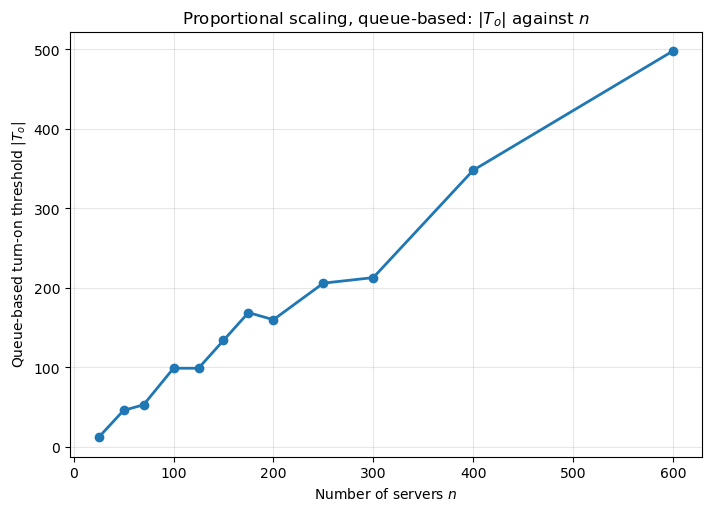

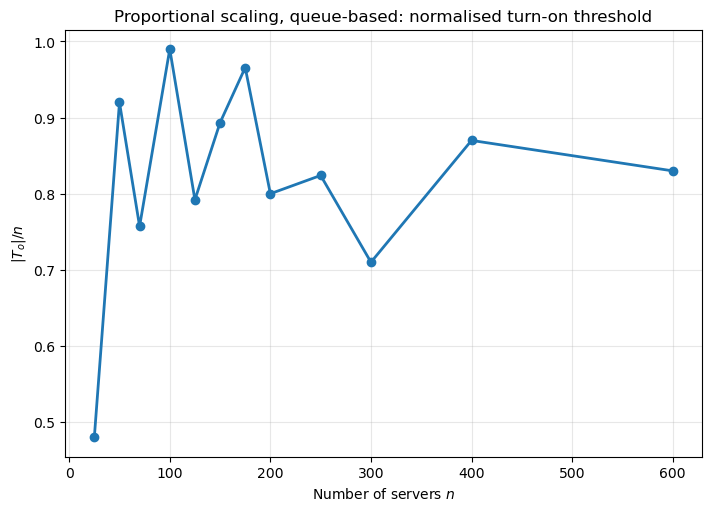

In [6]:
fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(
    queue_plot_df["num_servers"],
    queue_plot_df["abs_T_o"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("Number of servers $n$")
ax.set_ylabel("Queue-based turn-on threshold $|T_o|$")
ax.set_title("Proportional scaling, queue-based: $|T_o|$ against $n$")
ax.grid(alpha=0.3)

plt.savefig(
    FIGURE_DIR / "06_queue_based_proportional_abs_To_vs_n.png",
    dpi=DPI,
)

plt.show()

plot_threshold_ratio(
    queue_df,
    y_column="abs_T_o_over_n",
    y_label="$|T_o|/n$",
    title="Proportional scaling, queue-based: normalised turn-on threshold",
    filename="06_queue_based_proportional_To_over_n.png",
)


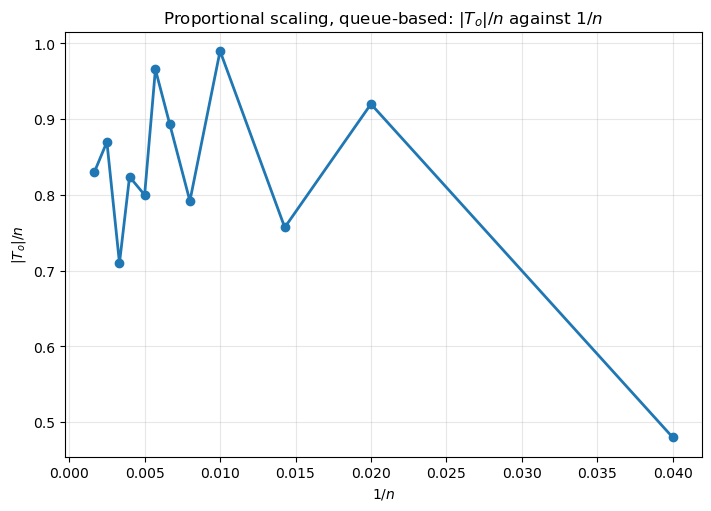

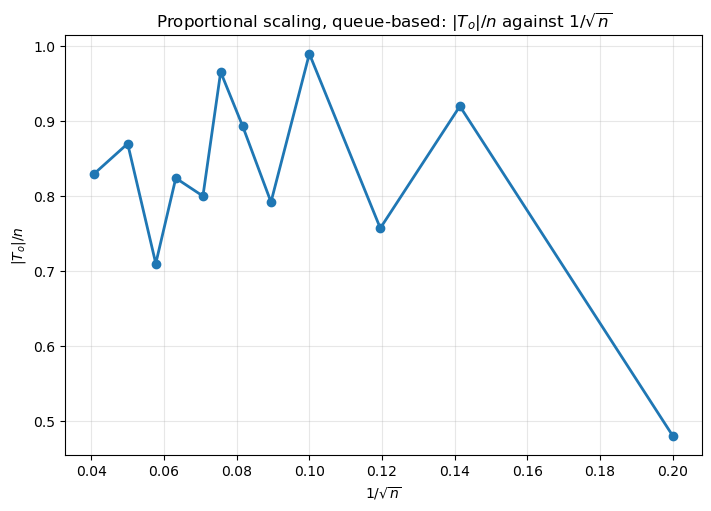

In [7]:
queue_plot_df = queue_plot_df.copy()
queue_plot_df["inv_n"] = 1 / queue_plot_df["num_servers"]
queue_plot_df["inv_sqrt_n"] = 1 / np.sqrt(queue_plot_df["num_servers"])

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(
    queue_plot_df["inv_n"],
    queue_plot_df["abs_T_o_over_n"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("$1/n$")
ax.set_ylabel("$|T_o|/n$")
ax.set_title("Proportional scaling, queue-based: $|T_o|/n$ against $1/n$")
ax.grid(alpha=0.3)

plt.savefig(
    FIGURE_DIR / "06_queue_based_proportional_abs_To_over_n_vs_inv_n.png",
    dpi=DPI,
)

plt.show()

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(
    queue_plot_df["inv_sqrt_n"],
    queue_plot_df["abs_T_o_over_n"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("$1/\\sqrt{n}$")
ax.set_ylabel("$|T_o|/n$")
ax.set_title("Proportional scaling, queue-based: $|T_o|/n$ against $1/\\sqrt{n}$")
ax.grid(alpha=0.3)

plt.savefig(
    FIGURE_DIR / "06_queue_based_proportional_abs_To_over_n_vs_inv_sqrt_n.png",
    dpi=DPI,
)

plt.show()


## IDLE-based Turn Off threshold $T_i$

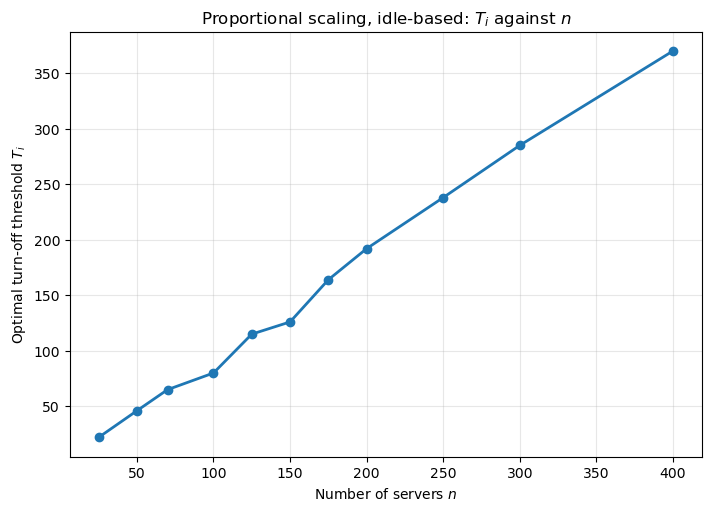

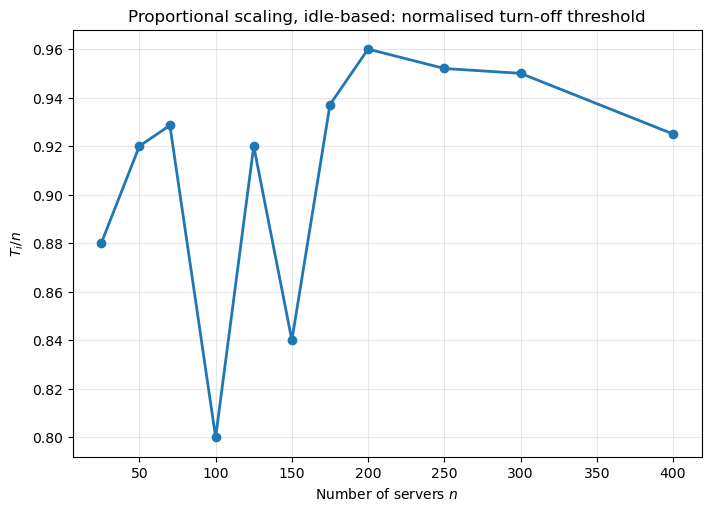

In [8]:
idle_plot_df = (
    idle_df
    .sort_values("num_servers")
    .copy()
)

# --------------------------------------------------
# 1. Raw relationship: T_i against n
# --------------------------------------------------
fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(
    idle_plot_df["num_servers"],
    idle_plot_df["best_T_i"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("Number of servers $n$")
ax.set_ylabel("Optimal turn-off threshold $T_i$")
ax.set_title("Proportional scaling, idle-based: $T_i$ against $n$")
ax.grid(alpha=0.3)

plt.savefig(
    FIGURE_DIR / "06_idle_based_proportional_Ti_vs_n.png",
    dpi=DPI,
)

plt.show()

plot_threshold_ratio(
    idle_df,
    y_column="T_i_over_n",
    y_label="$T_i/n$",
    title="Proportional scaling, idle-based: normalised turn-off threshold",
    filename="06_idle_based_proportional_Ti_over_n.png",
)

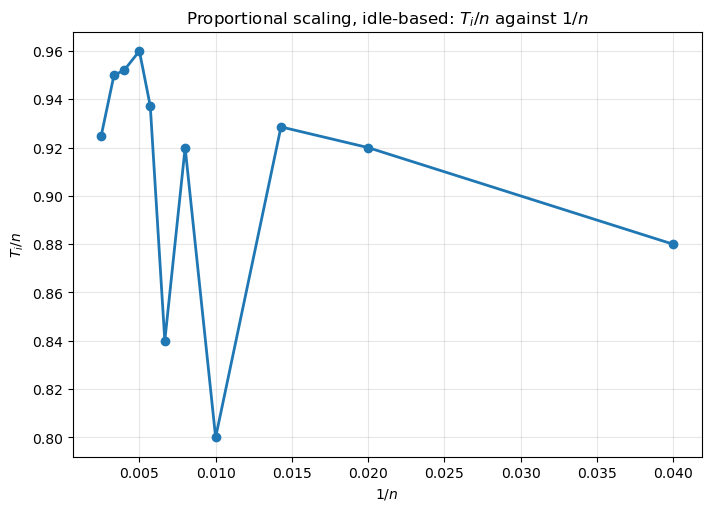

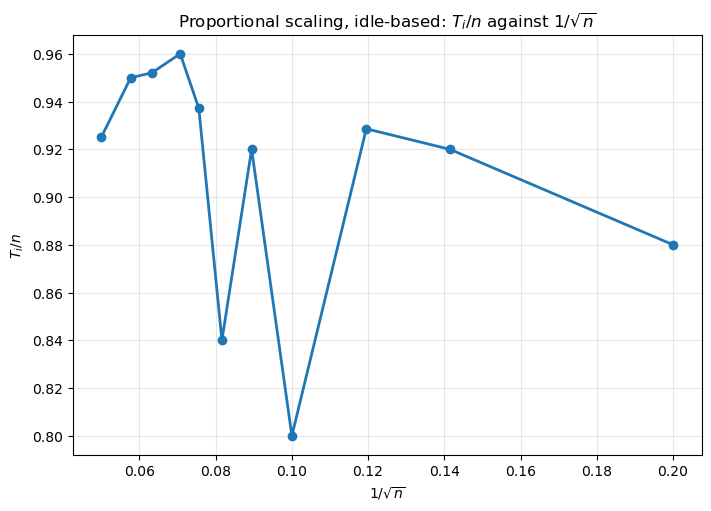

In [9]:
idle_plot_df = idle_plot_df.copy()
idle_plot_df["inv_n"] = 1 / idle_plot_df["num_servers"]
idle_plot_df["inv_sqrt_n"] = 1 / np.sqrt(idle_plot_df["num_servers"])

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(
    idle_plot_df["inv_n"],
    idle_plot_df["T_i_over_n"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("$1/n$")
ax.set_ylabel("$T_i/n$")
ax.set_title("Proportional scaling, idle-based: $T_i/n$ against $1/n$")
ax.grid(alpha=0.3)

plt.savefig(
    FIGURE_DIR / "06_idle_based_proportional_Ti_over_n_vs_inv_n.png",
    dpi=DPI,
)

plt.show()

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(
    idle_plot_df["inv_sqrt_n"],
    idle_plot_df["T_i_over_n"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("$1/\\sqrt{n}$")
ax.set_ylabel("$T_i/n$")
ax.set_title("Proportional scaling, idle-based: $T_i/n$ against $1/\\sqrt{n}$")
ax.grid(alpha=0.3)

plt.savefig(
    FIGURE_DIR / "06_idle_based_proportional_Ti_over_n_vs_inv_sqrt_n.png",
    dpi=DPI,
)

plt.show()


## IDLE-based Turn On threshold $T_o$

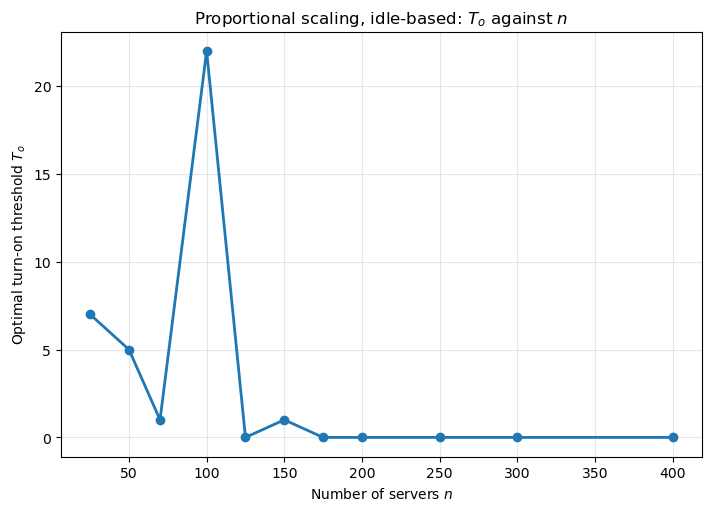

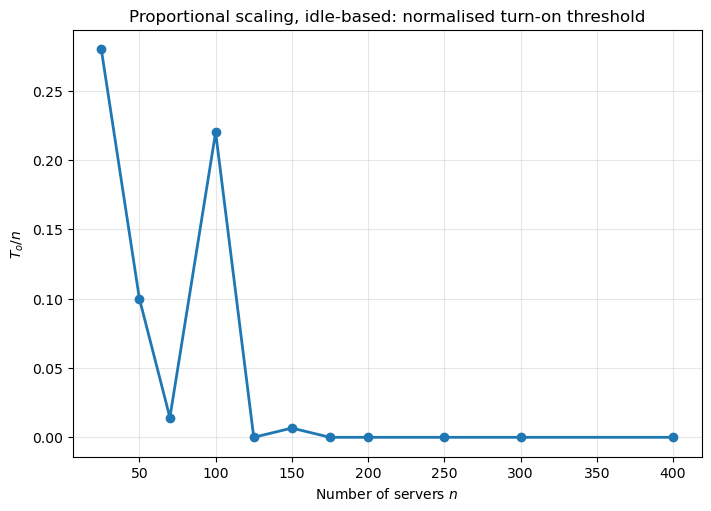

In [10]:
fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(
    idle_plot_df["num_servers"],
    idle_plot_df["best_T_o"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("Number of servers $n$")
ax.set_ylabel("Optimal turn-on threshold $T_o$")
ax.set_title("Proportional scaling, idle-based: $T_o$ against $n$")
ax.grid(alpha=0.3)

plt.savefig(
    FIGURE_DIR / "06_idle_based_proportional_To_vs_n.png",
    dpi=DPI,
)

plt.show()

plot_threshold_ratio(
    idle_df,
    y_column="T_o_over_n",
    y_label="$T_o/n$",
    title="Proportional scaling, idle-based: normalised turn-on threshold",
    filename="06_idle_based_proportional_To_over_n.png",
)

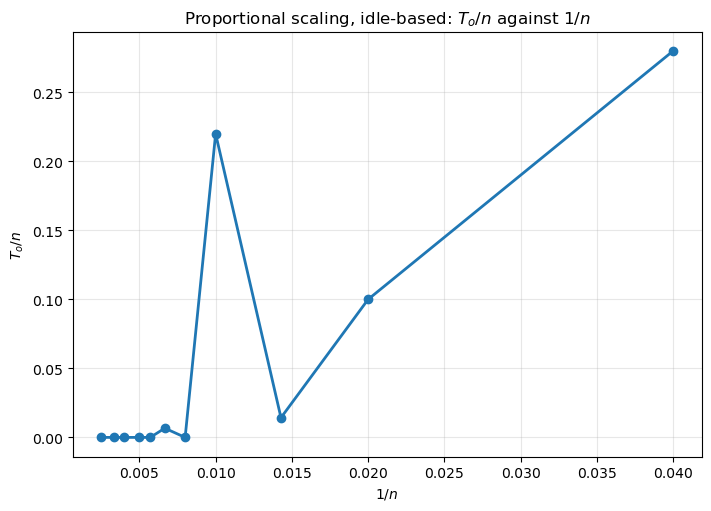

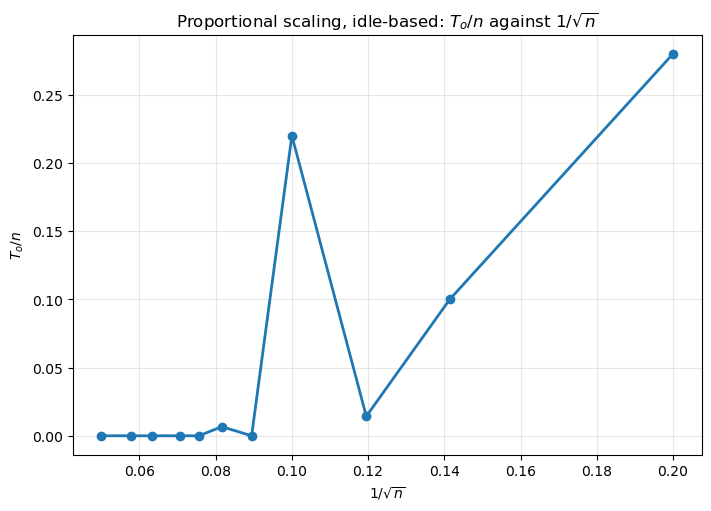

In [11]:
idle_plot_df = idle_plot_df.copy()
idle_plot_df["inv_n"] = 1 / idle_plot_df["num_servers"]
idle_plot_df["inv_sqrt_n"] = 1 / np.sqrt(idle_plot_df["num_servers"])

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(
    idle_plot_df["inv_n"],
    idle_plot_df["T_o_over_n"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("$1/n$")
ax.set_ylabel("$T_o/n$")
ax.set_title("Proportional scaling, idle-based: $T_o/n$ against $1/n$")
ax.grid(alpha=0.3)

plt.savefig(
    FIGURE_DIR / "06_idle_based_proportional_To_over_n_vs_inv_n.png",
    dpi=DPI,
)

plt.show()

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(
    idle_plot_df["inv_sqrt_n"],
    idle_plot_df["T_o_over_n"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("$1/\\sqrt{n}$")
ax.set_ylabel("$T_o/n$")
ax.set_title("Proportional scaling, idle-based: $T_o/n$ against $1/\\sqrt{n}$")
ax.grid(alpha=0.3)

plt.savefig(
    FIGURE_DIR / "06_idle_based_proportional_To_over_n_vs_inv_sqrt_n.png",
    dpi=DPI,
)

plt.show()


# Queue-based Model Fitness

In [12]:
model_df = (
    queue_df[["num_servers", "best_T_i"]]
    .copy()
    .dropna()
    .drop_duplicates(subset=["num_servers"])
    .sort_values("num_servers")
    .reset_index(drop=True)
)

model_df["num_servers"] = pd.to_numeric(model_df["num_servers"])
model_df["best_T_i"] = pd.to_numeric(model_df["best_T_i"])

n = model_df["num_servers"].to_numpy(dtype=float)
T_i = model_df["best_T_i"].to_numpy(dtype=float)

if len(model_df) < 3:
    raise ValueError("At least three system sizes are required for model fitting.")


def compute_r_squared(y_observed, y_fitted):
    ss_res = np.sum((y_observed - y_fitted) ** 2)
    ss_tot = np.sum((y_observed - y_observed.mean()) ** 2)
    return 1 - ss_res / ss_tot

## Model I: $T_i=an$

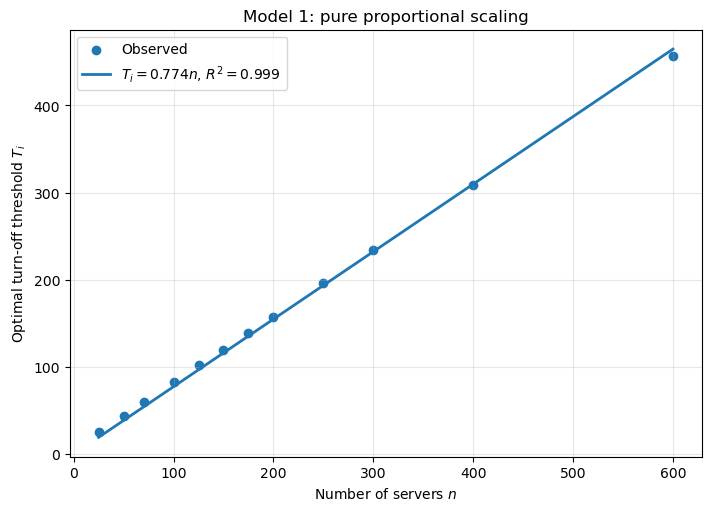

In [13]:
# --------------------------------------------------
# Model 1: T_i = a n
# --------------------------------------------------
a_prop = np.sum(n * T_i) / np.sum(n ** 2)
T_i_hat_prop = a_prop * n
r2_prop = compute_r_squared(T_i, T_i_hat_prop)

n_grid = np.linspace(n.min(), n.max(), 200)
T_i_grid_prop = a_prop * n_grid

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.scatter(
    n,
    T_i,
    label="Observed",
)

ax.plot(
    n_grid,
    T_i_grid_prop,
    linewidth=2,
    label=rf"$T_i = {a_prop:.3f}n$, $R^2={r2_prop:.3f}$",
)

ax.set_xlabel("Number of servers $n$")
ax.set_ylabel("Optimal turn-off threshold $T_i$")
ax.set_title("Model 1: pure proportional scaling")
ax.grid(alpha=0.3)
ax.legend()

plt.savefig(
    FIGURE_DIR / "06_queue_based_proportional_model_Ti_equals_an.png",
    dpi=DPI,
)

plt.show()

# Model II: $T_i = an+b$

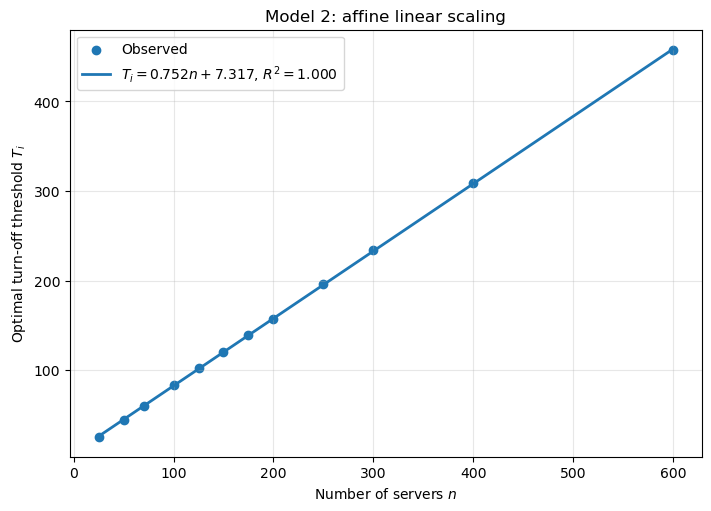

In [14]:
# --------------------------------------------------
# Model 2: T_i = a n + b
# --------------------------------------------------
X_affine = np.column_stack([n, np.ones(len(n))])
coef_affine, *_ = np.linalg.lstsq(X_affine, T_i, rcond=None)

a_affine = coef_affine[0]
b_affine = coef_affine[1]

T_i_hat_affine = a_affine * n + b_affine
r2_affine = compute_r_squared(T_i, T_i_hat_affine)

T_i_grid_affine = a_affine * n_grid + b_affine

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.scatter(
    n,
    T_i,
    label="Observed",
)

ax.plot(
    n_grid,
    T_i_grid_affine,
    linewidth=2,
    label=rf"$T_i = {a_affine:.3f}n + {b_affine:.3f}$, $R^2={r2_affine:.3f}$",
)

ax.set_xlabel("Number of servers $n$")
ax.set_ylabel("Optimal turn-off threshold $T_i$")
ax.set_title("Model 2: affine linear scaling")
ax.grid(alpha=0.3)
ax.legend()

plt.savefig(
    FIGURE_DIR / "06_queue_based_proportional_model_Ti_equals_an_plus_b.png",
    dpi=DPI,
)

plt.show()




# Model III: $T_i=an+b \sqrt{n}$

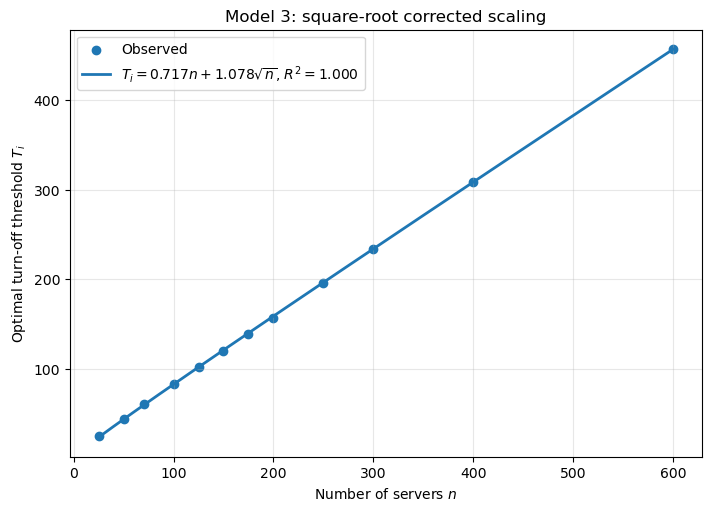

In [15]:
# --------------------------------------------------
# Model 3: T_i = a n + b sqrt(n)
# --------------------------------------------------
X_sqrt = np.column_stack([n, np.sqrt(n)])
coef_sqrt, *_ = np.linalg.lstsq(X_sqrt, T_i, rcond=None)

a_sqrt = coef_sqrt[0]
b_sqrt = coef_sqrt[1]

T_i_hat_sqrt = a_sqrt * n + b_sqrt * np.sqrt(n)
r2_sqrt = compute_r_squared(T_i, T_i_hat_sqrt)

T_i_grid_sqrt = a_sqrt * n_grid + b_sqrt * np.sqrt(n_grid)

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.scatter(
    n,
    T_i,
    label="Observed",
)

ax.plot(
    n_grid,
    T_i_grid_sqrt,
    linewidth=2,
    label=rf"$T_i = {a_sqrt:.3f}n + {b_sqrt:.3f}\sqrt{{n}}$, $R^2={r2_sqrt:.3f}$",
)

ax.set_xlabel("Number of servers $n$")
ax.set_ylabel("Optimal turn-off threshold $T_i$")
ax.set_title("Model 3: square-root corrected scaling")
ax.grid(alpha=0.3)
ax.legend()

plt.savefig(
    FIGURE_DIR / "06_queue_based_proportional_model_Ti_equals_an_plus_b_sqrt_n.png",
    dpi=DPI,
)

plt.show()

# IDLE-based Model Fitness

In [16]:
idle_model_df = (
    idle_df[["num_servers", "best_T_i"]]
    .copy()
    .dropna()
    .drop_duplicates(subset=["num_servers"])
    .sort_values("num_servers")
    .reset_index(drop=True)
)

idle_model_df["num_servers"] = pd.to_numeric(idle_model_df["num_servers"])
idle_model_df["best_T_i"] = pd.to_numeric(idle_model_df["best_T_i"])

idle_n = idle_model_df["num_servers"].to_numpy(dtype=float)
idle_T_i = idle_model_df["best_T_i"].to_numpy(dtype=float)

if len(idle_model_df) < 3:
    raise ValueError("At least three system sizes are required for model fitting.")

idle_n_grid = np.linspace(idle_n.min(), idle_n.max(), 200)


## Model I: $T_i=an$

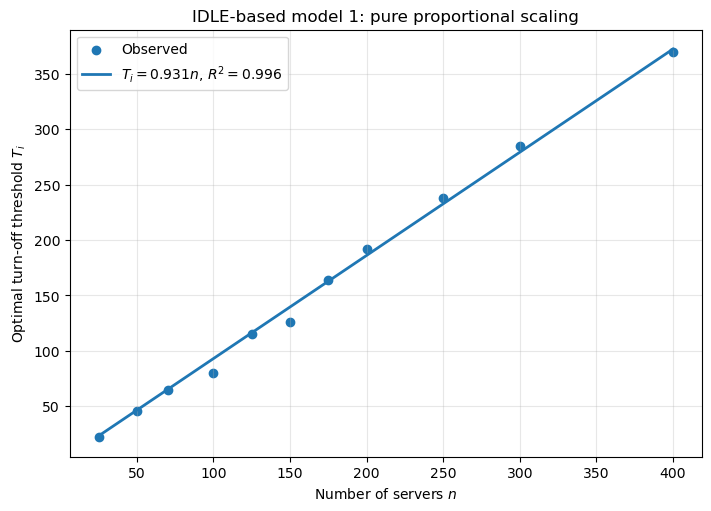

In [17]:
# --------------------------------------------------
# Model 1: T_i = a n
# --------------------------------------------------
idle_a_prop = np.sum(idle_n * idle_T_i) / np.sum(idle_n ** 2)
idle_T_i_hat_prop = idle_a_prop * idle_n
idle_r2_prop = compute_r_squared(idle_T_i, idle_T_i_hat_prop)

idle_T_i_grid_prop = idle_a_prop * idle_n_grid

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.scatter(
    idle_n,
    idle_T_i,
    label="Observed",
)

ax.plot(
    idle_n_grid,
    idle_T_i_grid_prop,
    linewidth=2,
    label=rf"$T_i = {idle_a_prop:.3f}n$, $R^2={idle_r2_prop:.3f}$",
)

ax.set_xlabel("Number of servers $n$")
ax.set_ylabel("Optimal turn-off threshold $T_i$")
ax.set_title("IDLE-based model 1: pure proportional scaling")
ax.grid(alpha=0.3)
ax.legend()

plt.savefig(
    FIGURE_DIR / "06_idle_based_proportional_model_Ti_equals_an.png",
    dpi=DPI,
)

plt.show()


# Model II: $T_i = an+b$

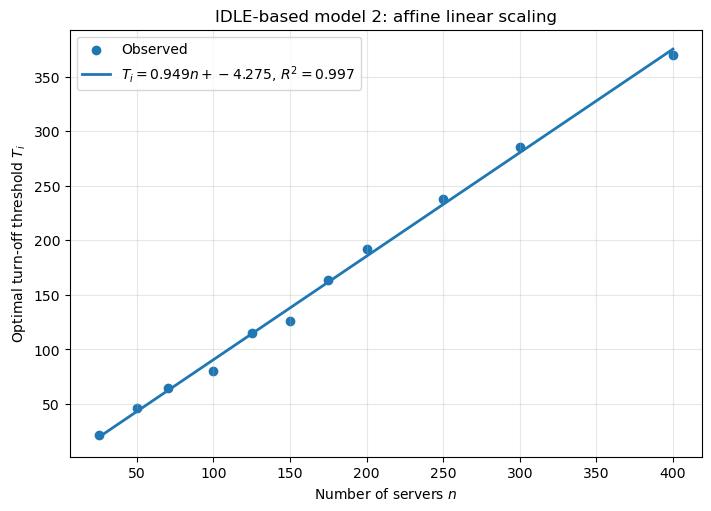

In [18]:
# --------------------------------------------------
# Model 2: T_i = a n + b
# --------------------------------------------------
idle_X_affine = np.column_stack([idle_n, np.ones(len(idle_n))])
idle_coef_affine, *_ = np.linalg.lstsq(idle_X_affine, idle_T_i, rcond=None)

idle_a_affine = idle_coef_affine[0]
idle_b_affine = idle_coef_affine[1]

idle_T_i_hat_affine = idle_a_affine * idle_n + idle_b_affine
idle_r2_affine = compute_r_squared(idle_T_i, idle_T_i_hat_affine)

idle_T_i_grid_affine = idle_a_affine * idle_n_grid + idle_b_affine

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.scatter(
    idle_n,
    idle_T_i,
    label="Observed",
)

ax.plot(
    idle_n_grid,
    idle_T_i_grid_affine,
    linewidth=2,
    label=rf"$T_i = {idle_a_affine:.3f}n + {idle_b_affine:.3f}$, $R^2={idle_r2_affine:.3f}$",
)

ax.set_xlabel("Number of servers $n$")
ax.set_ylabel("Optimal turn-off threshold $T_i$")
ax.set_title("IDLE-based model 2: affine linear scaling")
ax.grid(alpha=0.3)
ax.legend()

plt.savefig(
    FIGURE_DIR / "06_idle_based_proportional_model_Ti_equals_an_plus_b.png",
    dpi=DPI,
)

plt.show()


# Model III: $T_i=an+b \sqrt{n}$

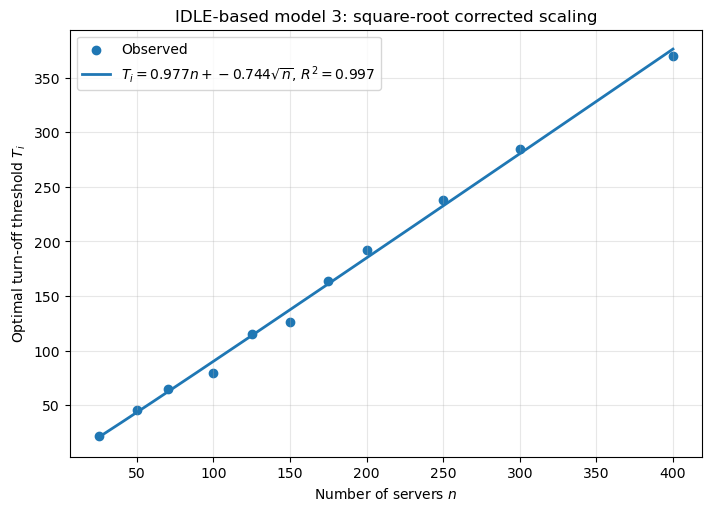

In [19]:
# --------------------------------------------------
# Model 3: T_i = a n + b sqrt(n)
# --------------------------------------------------
idle_X_sqrt = np.column_stack([idle_n, np.sqrt(idle_n)])
idle_coef_sqrt, *_ = np.linalg.lstsq(idle_X_sqrt, idle_T_i, rcond=None)

idle_a_sqrt = idle_coef_sqrt[0]
idle_b_sqrt = idle_coef_sqrt[1]

idle_T_i_hat_sqrt = idle_a_sqrt * idle_n + idle_b_sqrt * np.sqrt(idle_n)
idle_r2_sqrt = compute_r_squared(idle_T_i, idle_T_i_hat_sqrt)

idle_T_i_grid_sqrt = idle_a_sqrt * idle_n_grid + idle_b_sqrt * np.sqrt(idle_n_grid)

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.scatter(
    idle_n,
    idle_T_i,
    label="Observed",
)

ax.plot(
    idle_n_grid,
    idle_T_i_grid_sqrt,
    linewidth=2,
    label=rf"$T_i = {idle_a_sqrt:.3f}n + {idle_b_sqrt:.3f}\sqrt{{n}}$, $R^2={idle_r2_sqrt:.3f}$",
)

ax.set_xlabel("Number of servers $n$")
ax.set_ylabel("Optimal turn-off threshold $T_i$")
ax.set_title("IDLE-based model 3: square-root corrected scaling")
ax.grid(alpha=0.3)
ax.legend()

plt.savefig(
    FIGURE_DIR / "06_idle_based_proportional_model_Ti_equals_an_plus_b_sqrt_n.png",
    dpi=DPI,
)

plt.show()


# Policies Comparison

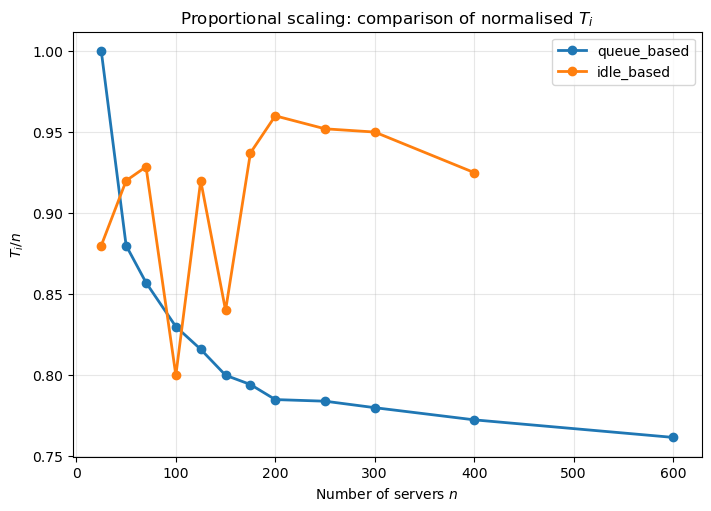

In [20]:
combined_df = pd.concat(
    [queue_df, idle_df],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

for mode, group in combined_df.groupby("turn_on_mode", sort=False):
    group = group.sort_values("num_servers")

    ax.plot(
        group["num_servers"],
        group["T_i_over_n"],
        marker="o",
        linewidth=2,
        label=mode,
    )

ax.set_xlabel("Number of servers $n$")
ax.set_ylabel("$T_i/n$")
ax.set_title("Proportional scaling: comparison of normalised $T_i$")
ax.grid(alpha=0.3)
ax.legend()

save_figure("06_proportional_comparison_Ti_over_n.png")

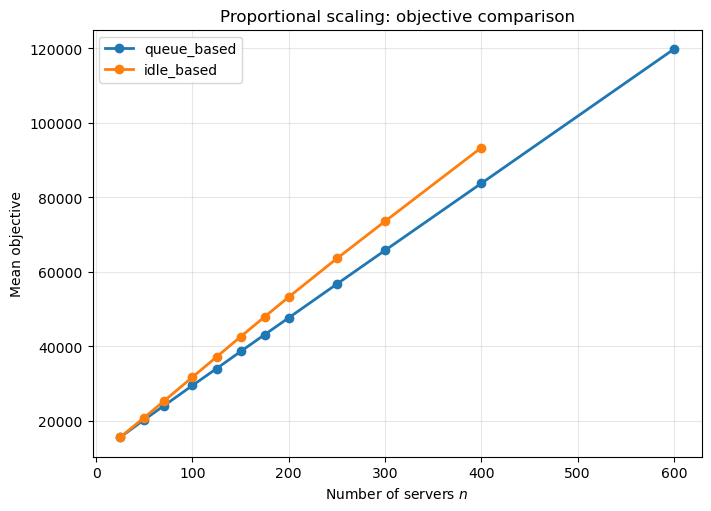

In [21]:
fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

for mode, group in combined_df.groupby("turn_on_mode", sort=False):
    group = group.sort_values("num_servers")

    ax.plot(
        group["num_servers"],
        group["mean_objective"],
        marker="o",
        linewidth=2,
        label=mode,
    )

ax.set_xlabel("Number of servers $n$")
ax.set_ylabel("Mean objective")
ax.set_title("Proportional scaling: objective comparison")
ax.grid(alpha=0.3)
ax.legend()

save_figure("06_proportional_comparison_objective.png")